<a href="https://colab.research.google.com/github/CodeWithYuva/Itech_internship/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mathiasviborg/uta-rldd-videos-cropped-by-faces")

print("Path to dataset files:", path)

100%|██████████| 6.24G/6.24G [01:20<00:00, 83.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mathiasviborg/uta-rldd-videos-cropped-by-faces/versions/1


In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.13


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 15.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.


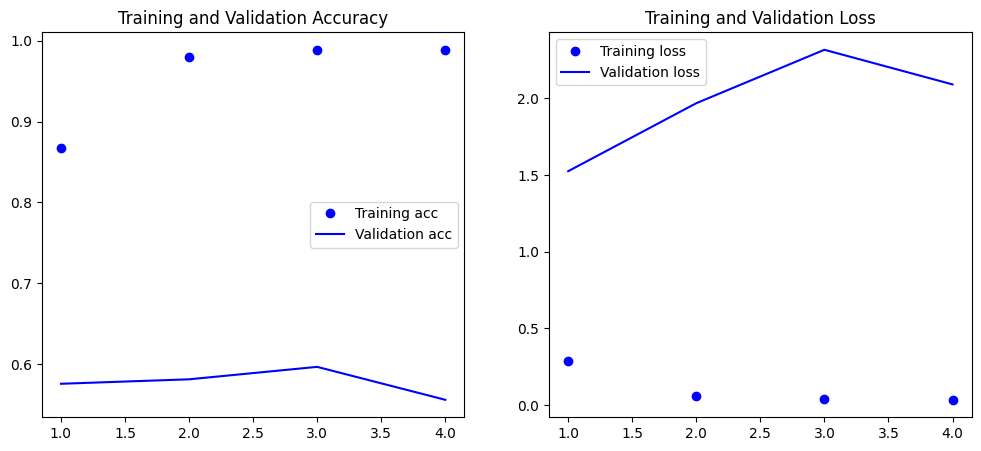

In [15]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [16]:
import tensorflow as tf

# 1. Load your trained model
model = tf.keras.models.load_model('best_drowsiness_model.keras')

# 2. Pick a video from your validation set to test
test_video_path = val_x[0]

# 3. Preprocess the video (using the same function as training)
test_data = preprocess_video(test_video_path, n_frames=10) # 10 because your summary shows 10 frames
test_data = np.expand_dims(test_data, axis=0) # Add batch dimension: (1, 10, 224, 224, 3)

# 4. Predict!
prediction = model.predict(test_data)
label = "DROWSY" if prediction[0][0] > 0.5 else "ALERT"

print(f"Prediction Score: {prediction[0][0]:.4f}")
print(f"Result: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Prediction Score: 0.0015
Result: ALERT


In [17]:
import numpy as np
import tensorflow as tf
import cv2

# 1. Load the model
model = tf.keras.models.load_model('best_drowsiness_model.keras')

def predict_single_video(video_path):
    # 2. Preprocess (Ensure N_FRAMES matches your training: 10)
    # The model summary you shared showed (None, 10, 1280), so we use 10 frames
    frames = preprocess_video(video_path, n_frames=10, target_size=(224, 224))

    # 3. Add Batch Dimension (1, 10, 224, 224, 3)
    input_tensor = np.expand_dims(frames, axis=0)

    # 4. Run Inference
    prediction = model.predict(input_tensor, verbose=0)[0][0]

    # 5. Interpret Results
    # 0.0 is Alert, 1.0 is Drowsy
    status = "DROWSY" if prediction > 0.5 else "ALERT"
    confidence = prediction if status == "DROWSY" else (1 - prediction)

    print("-" * 30)
    print(f"Video: {os.path.basename(video_path)}")
    print(f"Prediction: {status}")
    print(f"Confidence: {confidence * 100:.2f}%")
    print("-" * 30)

# Example usage:
# Replace with a path from your val_x list or a new uploaded file
test_path = "/content/video1.mp4"
predict_single_video(test_path)

------------------------------
Video: video1.mp4
Prediction: ALERT
Confidence: 99.48%
------------------------------


In [11]:
import os
import re
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# --- 1. CONFIGURATION ---
# The path you provided from kagglehub
DATA_PATH = "/root/.cache/kagglehub/datasets/mathiasviborg/uta-rldd-videos-cropped-by-faces/versions/1/UTA-RLDD Face Cropped Video"
N_FRAMES = 10
IMG_SIZE = (160, 160)
BATCH_SIZE = 16
EPOCHS = 10

# --- 2. VIDEO PREPROCESSING ---
def preprocess_video(video_path, n_frames=20, target_size=(224, 224)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_rate = max(1, total_frames // n_frames)

    for i in range(n_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip_rate)
        success, frame = cap.read()
        if not success:
            frame = np.zeros((*target_size, 3), dtype='uint8')
        else:
            frame = cv2.resize(frame, target_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return np.array(frames) / 255.0

# --- 3. DATA LISTING & SUBJECT-WISE SPLITTING ---
def create_split_data(base_dir):
    video_paths = []
    labels = []

    # Get all video paths and labels
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith(".mp4"):
                full_path = os.path.join(root, file)
                parent_dir_name = os.path.basename(root)
                if parent_dir_name == '0':
                    labels.append(0)
                elif parent_dir_name == '10':
                    labels.append(1)
                else:
                    continue
                video_paths.append(full_path)

    # Group by Subject ID to prevent data leakage
    subject_to_indices = {}
    for i, path in enumerate(video_paths):
        # Extract subject ID from the directory path: .../lenX/SubjectID/Label/video.mp4
        # root is .../lenX/SubjectID/Label
        # os.path.dirname(root) is .../lenX/SubjectID
        # os.path.basename(os.path.dirname(root)) is SubjectID
        subject_id = os.path.basename(os.path.dirname(os.path.dirname(path))) # Corrected logic to get SubjectID from path

        if subject_id not in subject_to_indices:
            subject_to_indices[subject_id] = []
        subject_to_indices[subject_id].append(i)

    # Split subjects 80/20
    unique_subjects = sorted(list(subject_to_indices.keys()))
    train_subs, val_subs = train_test_split(unique_subjects, test_size=0.2, random_state=42)

    def get_split(sub_list):
        paths, labs = [], []
        for s in sub_list:
            for idx in subject_to_indices[s]:
                paths.append(video_paths[idx])
                labs.append(labels[idx])
        return paths, labs

    train_x, train_y = get_split(train_subs)
    val_x, val_y = get_split(val_subs)

    return train_x, train_y, val_x, val_y

# --- 4. DATA GENERATOR ---
class DrowsinessGenerator(tf.keras.utils.Sequence):
    def __init__(self, video_paths, labels, batch_size=32, n_frames=20):
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.n_frames = n_frames
        # Pre-calculate indices to avoid dynamic calculation during training
        self.indices = np.arange(len(self.video_paths))

    def __len__(self):
        # Use a simple calculation that returns a plain integer
        return int(len(self.video_paths) // self.batch_size)

    def __getitem__(self, index):
        # 1. Get the batch of indices first
        start = index * self.batch_size
        end = (index + 1) * self.batch_size
        batch_indices = self.indices[start:end]

        X = []
        Y = []

        # 2. Loop through indices and load videos
        for i in batch_indices:
            try:
                # This calls your preprocess_video function
                video_data = preprocess_video(self.video_paths[i], n_frames=self.n_frames, target_size=IMG_SIZE)
                X.append(video_data)
                Y.append(self.labels[i])
            except Exception as e:
                # If one video is corrupt, we don't want to crash the whole batch
                continue

        # 3. Return as standard numpy arrays
        return np.array(X, dtype='float32'), np.array(Y, dtype='float32')

    def on_epoch_end(self):
        # Shuffle indices at the end of each epoch for better learning
        np.random.shuffle(self.indices)
    def on_epoch_end(self):
        # Shuffle data after each epoch to improve generalization
        np.random.shuffle(self.indices)
# --- 5. MODEL ARCHITECTURE (CNN + LSTM) ---
def build_model():
    base_cnn = tf.keras.applications.MobileNetV2(
        weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3), pooling='avg'
    )
    base_cnn.trainable = False

    model = models.Sequential([
        layers.TimeDistributed(base_cnn, input_shape=(N_FRAMES, *IMG_SIZE, 3)),
        layers.LSTM(64, dropout=0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- 6. EXECUTION ---
print("Preparing data lists...")
train_x, train_y, val_x, val_y = create_split_data(DATA_PATH)
print(f"Train videos: {len(train_x)} | Val videos: {len(val_x)}")

train_gen = DrowsinessGenerator(train_x, train_y, batch_size=BATCH_SIZE, n_frames=N_FRAMES)
val_gen = DrowsinessGenerator(val_x, val_y, batch_size=BATCH_SIZE, n_frames=N_FRAMES)

print("Building CNN-LSTM model...")
model = build_model()
model.summary()

# Callbacks for safety
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("best_drowsiness_model.keras", save_best_only=True)
]

print("Starting training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,steps_per_epoch=500
)

print("Training complete. Model saved as 'best_drowsiness_model.keras'.")

Preparing data lists...
Train videos: 22670 | Val videos: 5467
Building CNN-LSTM model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,606,529 (9.94 MB)

...

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Starting training...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 576s 1s/step - accuracy: 0.7580 - loss: 0.4716 - val_accuracy: 0.5759 - val_loss: 1.5248
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 491s 983ms/step - accuracy: 0.9778 - loss: 0.0680 - val_accuracy: 0.5814 - val_loss: 1.9680
Epoch 3/10
416/500 ━━━━━━━━━━━━━━━━━━━━ 46s 554ms/step - accuracy: 0.9882 - loss: 0.0406

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 412s 826ms/step - accuracy: 0.9883 - loss: 0.0402 - val_accuracy: 0.5968 - val_loss: 2.3161
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 502s 957ms/step - accuracy: 0.9869 - loss: 0.0386 - val_accuracy: 0.5561 - val_loss: 2.0904
Training complete. Model saved as 'best_drowsiness_model.keras'.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- 7. EVALUATION ---

# 1. Get all true labels and predictions from the validation generator
all_y_true = []
all_y_pred = []

for i in range(len(val_gen)):
    x, y = val_gen[i]
    preds = model.predict(x, verbose=0)
    all_y_true.extend(y)
    all_y_pred.extend([1 if p > 0.5 else 0 for p in preds])

# 2. Plot Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Alert', 'Drowsy'], yticklabels=['Alert', 'Drowsy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(all_y_true, all_y_pred))